# Week 7 Day 2

# "THE PRICE IS RIGHT" Capstone Project

This week - fine tune an open-source model!

A model that can estimate how much something costs, from its description.

# Order of play

DAY 1: QLoRA  
DAY 2: Prompt data and Base Model  
DAY 3: Train Part 1  
DAY 4: Train Part 2  
DAY 5: Eval

## First we need to upload the final dataset



In [14]:
import os

print(os.getcwd())

/content


In [16]:
import sys

print(sys.path[:5])

['/content', '/env/python', '/usr/lib/python313.zip', '/usr/lib/python3.13', '/usr/lib/python3.13/lib-dynload']


In [17]:
import sys

sys.path.insert(
    0,
    "/content/LLM_Engineering_opensource-main/LLM_Engineering_opensource-main/finetuning_frontier_model"
)

In [19]:
import os

print(os.getcwd())
print(os.listdir("/content"))

/content
['.config', 'items.py', 'evaluator.py', 'sample_data']


In [20]:
from items import Item

In [21]:
print(Item)

<class 'items.Item'>


In [22]:
import os

from dotenv import load_dotenv
from huggingface_hub import login
from items import Item

from tqdm.notebook import tqdm
from transformers import AutoTokenizer

import matplotlib.pyplot as plt

In [27]:
from google.colab import userdata

hf_token = userdata.get("HF_TOKEN")

In [29]:
from huggingface_hub import login

login(hf_token, add_to_git_credential=True)

In [30]:
LITE_MODE = False

from google.colab import userdata
from huggingface_hub import login

hf_token = userdata.get("HF_TOKEN")

login(hf_token, add_to_git_credential=True)

In [31]:
username = "AbhishekRavindran"
dataset = f"{username}/items_lite" if LITE_MODE else f"{username}/items_full"

train, val, test = Item.from_hub(dataset)
items = train + val + test

print(f"Loaded {len(train):,} training items, {len(val):,} validation items, {len(test):,} test items")

README.md:   0%|          | 0.00/744 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  243MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.04MB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/800000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Loaded 800,000 training items, 10,000 validation items, 10,000 test items


In [32]:
BASE_MODEL = "meta-llama/Llama-3.2-3B"

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

In [33]:
token_counts = [item.count_tokens(tokenizer) for item in tqdm(items)]

  0%|          | 0/820000 [00:00<?, ?it/s]

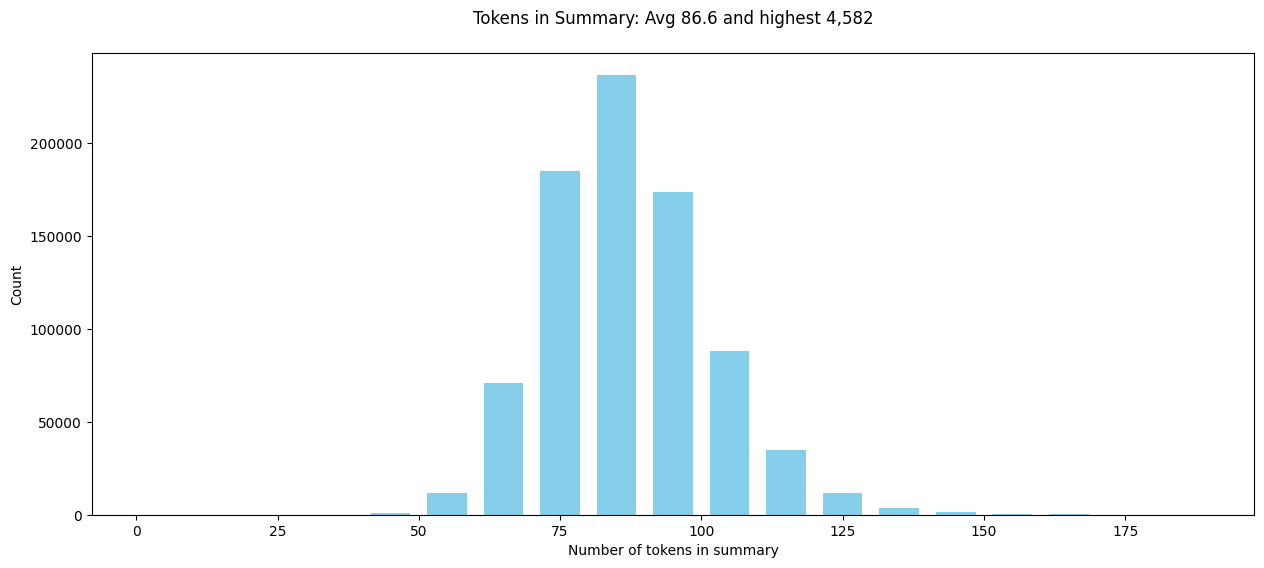

In [34]:
plt.figure(figsize=(15, 6))
plt.title(f"Tokens in Summary: Avg {sum(token_counts)/len(token_counts):,.1f} and highest {max(token_counts):,}\n")
plt.xlabel('Number of tokens in summary')
plt.ylabel('Count')
plt.hist(token_counts, rwidth=0.7, color="skyblue", bins=range(0, 200, 10))
plt.show()

In [35]:
CUTOFF = 110
cut = len([count for count in token_counts if count > CUTOFF])
print(f"With this CUTOFF, we will truncate {cut:,} items which is {cut/len(items):.1%}")


With this CUTOFF, we will truncate 47,083 items which is 5.7%


In [36]:
print(train[0].summary)

Title: Schlage F59 & 613 Andover Interior Knob (Deadbolt Included)  
Category: Home Hardware  
Brand: Schlage  
Description: A single‑piece oil‑rubbed bronze knob that mounts to a deadbolt for secure, easy interior door use.  
Details: Designed for a 4" minimum center‑to‑center door prep, it offers a lifetime mechanical and finish warranty and comes ready for quick installation.


In [37]:
for item in tqdm(train+val):
    item.make_prompts(tokenizer, CUTOFF, True)
for item in tqdm(test):
    item.make_prompts(tokenizer, CUTOFF, False)

  0%|          | 0/810000 [00:00<?, ?it/s]

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


  0%|          | 0/10000 [00:00<?, ?it/s]

In [39]:
print("PROMPT:")
print(test[0].prompt)
print("COMPLETION:")
print(test[0].completion)


PROMPT:
What does this cost to the nearest dollar?

Title: Excess V2 Distortion/Modulation Pedal  
Category: Music Pedals  
Brand: Old Blood Noise  
Description: A versatile pedal offering distortion and three modulation modes—delay, chorus, and harmonized fifths—with full control over signal routing and expression.  
Details: Features include separate gain, tone, and volume controls; time, depth, and volume per modulation; order switching, soft‑touch bypass, and expression jack for dynamic control.

Price is $
COMPLETION:
219.0


In [40]:
prompt_token_counts = [item.count_prompt_tokens(tokenizer) for item in tqdm(items)]

  0%|          | 0/820000 [00:00<?, ?it/s]

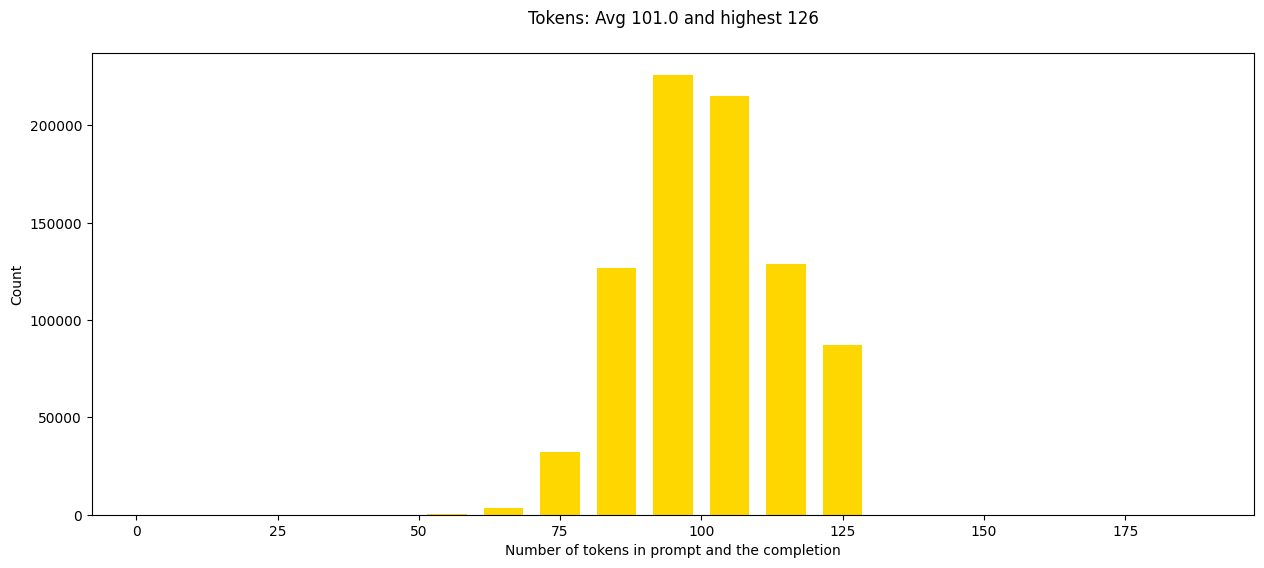

In [41]:
plt.figure(figsize=(15, 6))
plt.title(f"Tokens: Avg {sum(prompt_token_counts)/len(prompt_token_counts):,.1f} and highest {max(prompt_token_counts):,}\n")
plt.xlabel('Number of tokens in prompt and the completion')
plt.ylabel('Count')
plt.hist(prompt_token_counts, rwidth=0.7, color="gold", bins=range(0, 200, 10))
plt.show()

In [43]:
username = "Sudeepmattikoppa"
dataset = f"{username}/items_prompts_lite" if LITE_MODE else f"{username}/items_prompts_full"

Item.push_prompts_to_hub(dataset, train, val, test)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/800 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :  50%|####9     | 87.2MB /  175MB            

...

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/10 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|#########9| 2.20MB / 2.21MB            

Here are the datasets in HuggingFace:

https://huggingface.co/datasets/AbhishekRavindran/items_prompts_lite

https://huggingface.co/datasets/AbhishekRavindran/items_prompts_full

Please see this notebook in Google Colab:https://colab.research.google.com/drive/18NXaOLvucUpPt91Zo8FftHkssUMuPAEo#scrollTo=uuTX-xonNeOK

else use the below

# The Price is Right

### Week 7 Day 2

Selecting our model and evaluating the base model against the task.

Keep in mind: our base model has 8 billion params, quantized down to 4 bits
Compared with GPT-5 at TRILLIONS of params!

In [6]:
!pip install -q --upgrade bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 18.0 MB/s eta 0:00:00


In [9]:
import os

print(os.path.exists("/content/evaluator.py"))

True


In [10]:
import evaluator

print(dir(evaluator))

['COLOR_MAP', 'DEFAULT_SIZE', 'GREEN', 'RED', 'RESET', 'Tester', 'ThreadPoolExecutor', 'WORKERS', 'YELLOW', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'accumulate', 'evaluate', 'go', 'math', 'mean_squared_error', 'pd', 'px', 'r2_score', 're', 'tqdm']


In [11]:
import os
import re
import math
from tqdm import tqdm
from google.colab import userdata
from huggingface_hub import login

import torch
import transformers

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    set_seed
)

from peft import LoraConfig, PeftModel
from datasets import load_dataset, Dataset, DatasetDict
from datetime import datetime
import matplotlib.pyplot as plt

from evaluator import evaluate

In [12]:
# Constants

BASE_MODEL = "meta-llama/Llama-3.2-3B"
PROJECT_NAME = "price"

LITE_MODE = True

DATA_USER = "AbhishekRavindran"
DATASET_NAME = f"{DATA_USER}/items_prompts_lite" if LITE_MODE else f"{DATA_USER}/items_prompts_full"

# Hyper-parameters

QUANT_4_BIT = True

### Log in to HuggingFace

If you don't already have a HuggingFace account, visit https://huggingface.co to sign up and create a token.

Then select the Secrets for this Notebook by clicking on the key icon in the left, and add a new secret called `HF_TOKEN` with the value as your token.

In [13]:
# Log in to HuggingFace

hf_token = userdata.get('HF_TOKEN')
login(hf_token, add_to_git_credential=True)

# Load our data

We uploaded it to Hugging Face, so it's easy to retrieve it now

In [14]:
dataset = load_dataset(DATASET_NAME)
train = dataset['train']
val = dataset['val']
test = dataset['test']

README.md:   0%|          | 0.00/509 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 4.31MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/val-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  216kB            

data/val-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  218kB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [15]:
train[0]

{'prompt': 'What does this cost to the nearest dollar?\n\nTitle: Schlage F59 & 613 Andover Interior Knob (Deadbolt Included)  \nCategory: Home Hardware  \nBrand: Schlage  \nDescription: A single‑piece oil‑rubbed bronze knob that mounts to a deadbolt for secure, easy interior door use.  \nDetails: Designed for a 4" minimum center‑to‑center door prep, it offers a lifetime mechanical and finish warranty and comes ready for quick installation.\n\nPrice is $',
 'completion': '64.00'}

# Prepare our Base Llama Model for evaluation

Load our base model with 4 bit quantization and try out 1 example

In [16]:
## pick the right quantization

if QUANT_4_BIT:
  quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4"
  )
else:
  quant_config = BitsAndBytesConfig(
    load_in_8bit=True,
    bnb_8bit_compute_dtype=torch.bfloat16
  )

In [17]:
# Load the Tokenizer and the Model

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=quant_config,
    device_map="auto",
)
base_model.generation_config.pad_token_id = tokenizer.pad_token_id

print(f"Memory footprint: {base_model.get_memory_footprint() / 1e9:.1f} GB")

config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

Memory footprint: 2.2 GB


In [18]:
def model_predict(item):
    inputs = tokenizer(item["prompt"],return_tensors="pt").to("cuda")
    with torch.no_grad():
        output_ids = base_model.generate(**inputs, max_new_tokens=8)
    prompt_len = inputs["input_ids"].shape[1]
    generated_ids = output_ids[0, prompt_len:]
    return tokenizer.decode(generated_ids)

In [19]:
test[0]

{'prompt': 'What does this cost to the nearest dollar?\n\nTitle: Excess V2 Distortion/Modulation Pedal  \nCategory: Music Pedals  \nBrand: Old Blood Noise  \nDescription: A versatile pedal offering distortion and three modulation modes—delay, chorus, and harmonized fifths—with full control over signal routing and expression.  \nDetails: Features include separate gain, tone, and volume controls; time, depth, and volume per modulation; order switching, soft‑touch bypass, and expression jack for dynamic control.\n\nPrice is $',
 'completion': '219.0'}

In [1]:
!nvidia-smi

Sun Aug 23 08:30:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8


In [3]:
print(torch.cuda.get_device_name(0))

Tesla T4


In [20]:
print("test exists:", "test" in globals())
print("model exists:", "model" in globals())
print("tokenizer exists:", "tokenizer" in globals())

test exists: True
model exists: False
tokenizer exists: True


In [21]:
model_predict(test[0])

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


'399.00. ## Discussion ### '

# Evaluation!

Trying out our base Llama 3.2 model against the Test dataset

In [23]:
print(type(test[0]))
print(test[0])

<class 'dict'>
{'prompt': 'What does this cost to the nearest dollar?\n\nTitle: Excess V2 Distortion/Modulation Pedal  \nCategory: Music Pedals  \nBrand: Old Blood Noise  \nDescription: A versatile pedal offering distortion and three modulation modes—delay, chorus, and harmonized fifths—with full control over signal routing and expression.  \nDetails: Features include separate gain, tone, and volume controls; time, depth, and volume per modulation; order switching, soft‑touch bypass, and expression jack for dynamic control.\n\nPrice is $', 'completion': '219.0'}


In [25]:
from items import Item

In [29]:
import inspect

print(inspect.signature(Item))

(*, title: str, category: str, price: float, full: Optional[str] = None, weight: Optional[float] = None, summary: Optional[str] = None, prompt: Optional[str] = None, completion: Optional[str] = None, id: Optional[int] = None) -> None


In [28]:
from items import Item

In [31]:
import inspect

print(inspect.getsource(Item))

class Item(BaseModel):
    """
    An Item is a data-point of a Product with a Price
    """

    title: str
    category: str
    price: float
    full: Optional[str] = None
    weight: Optional[float] = None
    summary: Optional[str] = None
    prompt: Optional[str] = None
    completion: Optional[str] = None
    id: Optional[int] = None

    def make_prompt(self, text: str):
        self.prompt = f"{QUESTION}\n\n{text}\n\n{PREFIX}{round(self.price)}.00"

    def test_prompt(self) -> str:
        return self.prompt.split(PREFIX)[0] + PREFIX

    def __repr__(self) -> str:
        return f"<{self.title} = ${self.price}>"

    @staticmethod
    def push_to_hub(dataset_name: str, train: list[Self], val: list[Self], test: list[Self]):
        """Push Item lists to HuggingFace Hub"""
        DatasetDict(
            {
                "train": Dataset.from_list([item.model_dump() for item in train]),
                "validation": Dataset.from_list([item.model_dump() for item in val]),
   

In [33]:
print(Item.__annotations__)

{'title': <class 'str'>, 'category': <class 'str'>, 'price': <class 'float'>, 'full': typing.Optional[str], 'weight': typing.Optional[float], 'summary': typing.Optional[str], 'prompt': typing.Optional[str], 'completion': typing.Optional[str], 'id': typing.Optional[int]}


In [35]:
print(test[0])

{'prompt': 'What does this cost to the nearest dollar?\n\nTitle: Excess V2 Distortion/Modulation Pedal  \nCategory: Music Pedals  \nBrand: Old Blood Noise  \nDescription: A versatile pedal offering distortion and three modulation modes—delay, chorus, and harmonized fifths—with full control over signal routing and expression.  \nDetails: Features include separate gain, tone, and volume controls; time, depth, and volume per modulation; order switching, soft‑touch bypass, and expression jack for dynamic control.\n\nPrice is $', 'completion': '219.0'}


In [38]:
from huggingface_hub import list_datasets

for ds in list_datasets(author="AbhishekRavindran"):
    print(ds.id)

AbhishekRavindran/items_lite
AbhishekRavindran/items_raw_lite
AbhishekRavindran/items_full
AbhishekRavindran/items_prompts_lite
AbhishekRavindran/items_prompts_full


In [39]:
from huggingface_hub import list_datasets

print("Datasets available:")

for ds in list_datasets(author="AbhishekRavindran"):
    print(ds.id)

Datasets available:
AbhishekRavindran/items_lite
AbhishekRavindran/items_raw_lite
AbhishekRavindran/items_full
AbhishekRavindran/items_prompts_lite
AbhishekRavindran/items_prompts_full


In [40]:
train_items, val_items, test_items = Item.from_hub(
    "AbhishekRavindran/items_raw_lite"
)

README.md:   0%|          | 0.00/738 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.8MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.04MB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.06MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [41]:
print(type(test_items[0]))
print(test_items[0])
print("Price:", test_items[0].price)

<class 'items.Item'>
title='Old Blood Noise Excess V2 Distortion Chorus/Delay Pedal' category='Musical_Instruments' price=219.0 full='Old Blood Noise Excess V2 Distortion Chorus/Delay Pedal\n[\'Expanding on the Excess, Old Blood Noise continues their journey to revive and expand sought-out pedal sounds of the 80s. With delay, chorus, and harmonized fifths available along with distortion in series or parallel configurations, Excess V2 unveils more sounds and even more control.\']\n[\'Three modes of modulation (Delay, Chorus, and Fifth) each with Time, Depth, and Volume controls\', \'Distortion section with control over Gain, Tone, and Volume to access light overdrive through fuzzy distortion\', \'Order switching to run Distortion into Modulation, Modulation into Distortion, or separate parallel paths\', \'Soft touch switching and true relay bypass for each section\', \'Expression jack to externally control Rate and Depth\', \'Internal trimpot to set wet-dry mix of Modulation section\', 

In [43]:
print("Title:", test_items[0].title)
print("Price:", test_items[0].price)
print("Prompt:", test_items[0].prompt)
print("Completion:", test_items[0].completion)

Title: Old Blood Noise Excess V2 Distortion Chorus/Delay Pedal
Price: 219.0
Prompt: None
Completion: None


In [44]:
print(len(test))
print(len(test_items))

print(test[0]["completion"])
print(test_items[0].price)

print(test[0]["prompt"][:200])
print(test_items[0].title)

1000
1000
219.0
219.0
What does this cost to the nearest dollar?

Title: Excess V2 Distortion/Modulation Pedal  
Category: Music Pedals  
Brand: Old Blood Noise  
Description: A versatile pedal offering distortion and thre
Old Blood Noise Excess V2 Distortion Chorus/Delay Pedal


In [55]:
evaluation_test = [
    EvaluationItem(
        prompt=test[i]["prompt"],
        price=test_items[i].price,
        title=test_items[i].title
    )
    for i in range(len(test))
]

In [56]:
print(type(evaluation_test[0]))
print(evaluation_test[0].prompt[:100])
print(evaluation_test[0].price)

<class '__main__.EvaluationItem'>
What does this cost to the nearest dollar?

Title: Excess V2 Distortion/Modulation Pedal  
Category:
219.0


In [57]:
result = model_predict(evaluation_test[0])
print(result)

399.00, but I don't


In [58]:
evaluate(model_predict, evaluation_test)

  0%|          | 0/200 [00:00<?, ?it/s]

$19 $91 $5 $20 $20 $203 $137 $179 $26 $970 $1087 $199 $7 $38 $21 $22 $69 $21 $140 $108 $124 $16 $45 $25 $232 $253 $405 $5 $0 $70 $1 $30 $40 $59 $65 $181 $57 $45 $114 $33 $192 $74 $27 $214 $210 $13 $1 $2 $85 $102 $34 $121 $275 $30 $97 $120 $1 $15 $52 $6 $36 $22 $87 $10 $603 $40 $40 $655 $75 $44 $22 $13 $235 $14 $40 $27 $426 $4 $14 $11 $30 $1 $30 $89 $19 $40 $82 $157 $90 $31 $18 $70 $10 $5 $2 $48 $15 $57 $259 $450 $50 $92 $30 $59 $236 $2 $16 $370 $26 $1701 $39 $686 $11 $115 $4 $1830 $1 $17 $94 $96 $5 $61 $34 $157 $197 $70 $10 $39 $79 $126 $35 $77 $11 $15 $50 $4 $175 $80 $28 $162 $116 $249 $75 $15 $83 $68 $45 $330 $65 $33 $14 $999894 $37 $110 $16 $189 $31 $51 $160 $40 $11 $23 $33 $3 $240 $18 $48 $20 $30 $40 $15 $5 $220 $18 $67 $29 $12 $60 $70 $93 $154 $5 $100 $168 $70 $12 $63 $47 $42 $21 $5 $50 $28 $59 $100 $20 $30 $180 $42 $1 